# LAB 23 Evaluacion de modelos de regresión

## MAE, MSE, RMSE, R2

In [1]:
#Importamos librerias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
    )

In [2]:
#importamos el dataset
diabetes = load_diabetes(as_frame=True)
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


#Seleccion de variables predictoras y variables objetivos
#Hipótesis
Existe una relación entre las variables clinicas del paciente y la propagación de la diabetes 1 año despues

In [6]:
X = df.drop( columns="target")

In [7]:
y = df["target"]

In [8]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


# Separación de datos para el entrenamiento y prueba

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

#Entrenamiento

In [10]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

#Predicciones

In [11]:
prediccion = modelo.predict(X_test)

In [12]:
import matplotlib.pyplot as plt

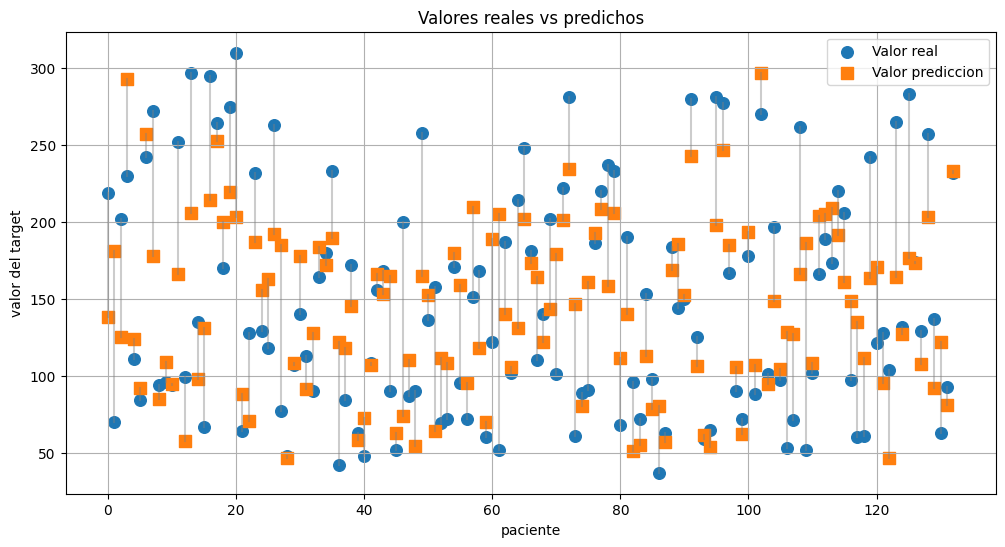

In [14]:
comparacion = pd.DataFrame({
    "real": y_test.values,
    "prediccion": prediccion
}).reset_index(drop=True)

#Grafica
plt.figure(figsize=(12, 6))
for i in range (len (comparacion)):
    plt.plot (
        [i,i],
        [comparacion["real"][i],comparacion["prediccion"][i]],
        color =  "gray",
        alpha=0.4,
    )
plt.scatter(
    comparacion.index,
    comparacion["real"],
    label = "Valor real",
    marker = "o",
    s = 70
)

plt.scatter(
    comparacion.index,
    comparacion["prediccion"],
    label = "Valor prediccion",
    marker = "s",
    s = 70
)

plt.xlabel("paciente")
plt.ylabel("valor del target")
plt.title("Valores reales vs predichos")
plt.legend()
plt.grid(True)
plt.show()

#Metricas

In [15]:
#MAE
mae = mean_absolute_error(y_test, prediccion)
print(f"MAE: {mae:.2f}")


MAE: 41.92


In [16]:
#MSE
mse = mean_squared_error(y_test, prediccion)
print(f"MSE: {mse:.2f}")

MSE: 2821.75


In [17]:
#RMSE
rmse = root_mean_squared_error(y_test, prediccion)
print(f"RMSE: {rmse:.2f}")

RMSE: 53.12


In [18]:
#Coeficiente de deteerminacion R2
r2 = r2_score(y_test, prediccion)
print(f"R2: {r2:.2f}")

R2: 0.48
